# 8.4 Sigma Sweep Test Run (6D z)
Testing 6D multivariate-normal batch-shift sigma sweep code with sigma = 0.5 for all four models (dim_z=6 for all models, matching the 6D simulated z space). Results include    
a) learned vs latent pseudotime could be plotted for each model.  
b) learned vs latent z space could be plotted for each model (6D ground truth vs 6D learned decipher_z, compared via silhouette score and UMAP).  

## Import modules

In [1]:
import sys
sys.path.insert(0, "/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation")

from sigma_sweep_6dz import rho_for_run

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## Test Run for Base Decipher
Testing vanilla Decipher at sigma=0.5, seed=0, decipher_seed=1, dim_z=6

Epoch 103 (batch 22/22) | | train elbo: 66.27 (last epoch: 66.27) | val ll: 76.35:  10%|█         | 103/1000 [00:21<03:10,  4.71it/s]2026-07-23 18:48:23,101 | INFO : Early stopping has been triggered.
2026-07-23 18:48:23,103 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-07-23 18:48:23,103 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-07-23 18:48:23,105 | INFO : Saving decipher model with run_id 2026-07-23-18-48-23-quantum-crabby-pie.


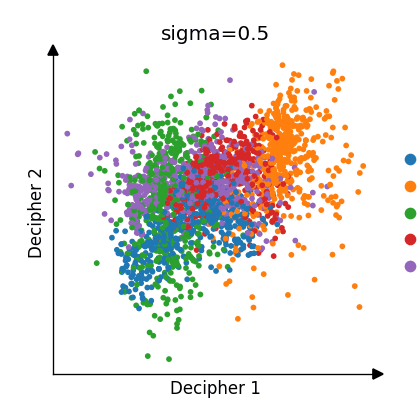

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
2026-07-23 18:48:23,358 | INFO : Clustering cells using scanpy Leiden algorithm.
2026-07-23 18:48:23,358 | INFO : Step 1: Computing neighbors with `sc.pp.neighbors`, with the representation decipher_z.
2026-07-23 18:48:25,653 | INFO : Step 2: Computing clusters with `sc.tl.leiden`, and resolution 0.05.
/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/native-decipher/decipher/tools/trajectory_inference.py:225: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(
2026-07-23 18:48:25,834 | INFO : Added `.o

rho = 0.1393
ground truth: /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/6dz_shift_sigma_sweep/0723_vz_sigma0.50.h5ad
trained:      /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/6dz_shift_sigma_sweep/trained/decipher/sigma0.5_seed0_decipher.h5ad


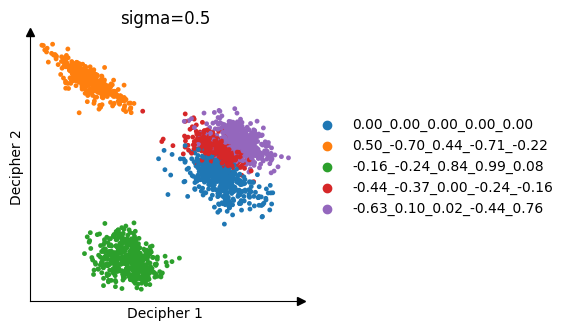

In [2]:
rho, gt_path, trained_path, adata = rho_for_run(sigma=0.5, seed=0, model="decipher", decipher_seed=1)
print(f"rho = {rho:.4f}")
print(f"ground truth: {gt_path}")
print(f"trained:      {trained_path}")

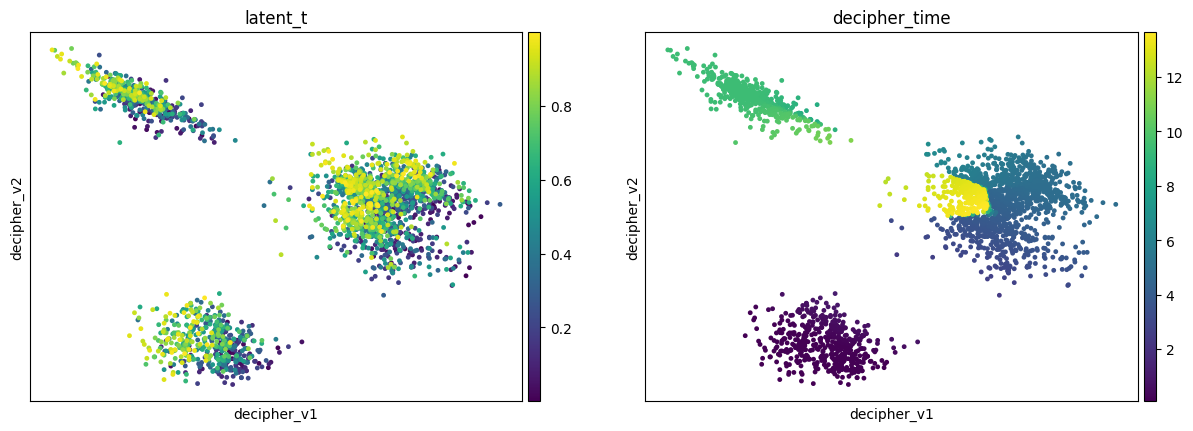

rho = 0.1393


In [3]:
import scanpy as sc

sc.pl.embedding(adata, basis="decipher_v", color=["latent_t", "decipher_time"])
print(f"rho = {rho:.4f}")

sigma=0.5  ground truth z silhouette (by batch) = 0.5256
sigma=0.5  learned decipher_z silhouette (by batch) = 0.5878


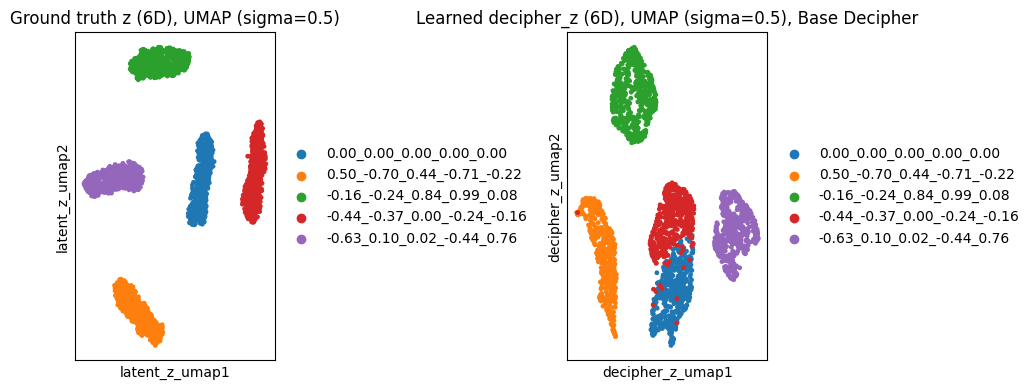

In [4]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# --- Quantitative: silhouette score directly on raw feature space (no projection) ---
# Ground truth uses all 6 latent_z dims (not just latent_z0/latent_z1) since the
# batch shift is now a 6D multivariate-normal vector applied across all dims.
batch_labels = adata.obs["batch"].astype(str)

sil_ground_truth = silhouette_score(
    adata.obs[["latent_z0", "latent_z1", "latent_z2", "latent_z3", "latent_z4", "latent_z5"]].values, batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
sil_learned = silhouette_score(
    adata.obsm["decipher_z"], batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
print(f"sigma={0.5}  ground truth z silhouette (by batch) = {sil_ground_truth:.4f}")
print(f"sigma={0.5}  learned decipher_z silhouette (by batch) = {sil_learned:.4f}")

# --- Qualitative: UMAP of ground truth z (6D, was a direct 2D scatter) vs. UMAP of learned decipher_z (6D) ---
adata.obsm["latent_z"] = adata.obs[["latent_z0", "latent_z1", "latent_z2", "latent_z3", "latent_z4", "latent_z5"]].values
sc.pp.neighbors(adata, use_rep="latent_z", key_added="latent_z_neighbors", random_state=42)
sc.tl.umap(adata, neighbors_key="latent_z_neighbors", random_state=42)
adata.obsm["latent_z_umap"] = adata.obsm["X_umap"]

sc.pp.neighbors(adata, use_rep="decipher_z", random_state=42)
sc.tl.umap(adata, random_state=42)
adata.obsm["decipher_z_umap"] = adata.obsm["X_umap"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
sc.pl.embedding(adata, basis="latent_z_umap", color="batch",
                ax=axes[0], show=False, title=f"Ground truth z (6D), UMAP (sigma={0.5})")
sc.pl.embedding(adata, basis="decipher_z_umap", color="batch",
                ax=axes[1], show=False, title=f"Learned decipher_z (6D), UMAP (sigma={0.5}), Base Decipher")
plt.tight_layout()
plt.show()

## Test Run for Decipher-vz
Testing decipher_vz (batch conditioning for z along decoder) at sigma=0.5, seed=0, decipher_seed=1, dim_z=6

Epoch 117 (batch 22/22) | | train elbo: 62.53 (last epoch: 62.53) | val ll: 73.62:  12%|█▏        | 117/1000 [00:24<03:02,  4.84it/s]2026-07-23 18:48:53,886 | INFO : Early stopping has been triggered.
2026-07-23 18:48:53,888 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-07-23 18:48:53,888 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-07-23 18:48:53,889 | INFO : Saving decipher model with run_id 2026-07-23-18-48-53-concave-brown-relative.


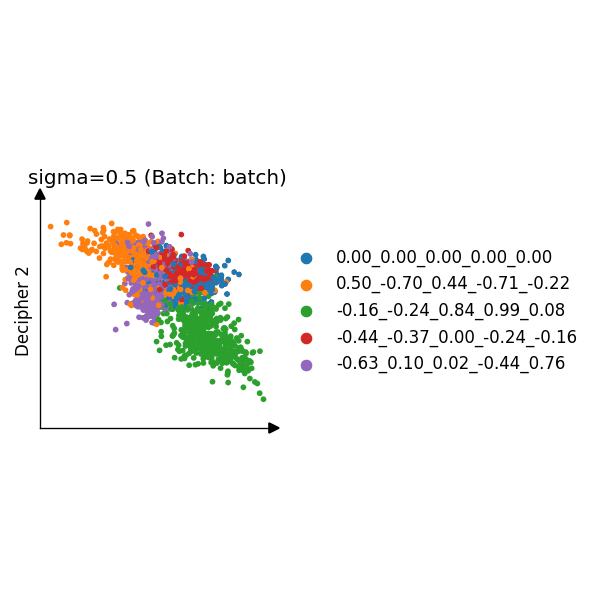

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
2026-07-23 18:48:54,277 | INFO : Clustering cells using scanpy Leiden algorithm.
2026-07-23 18:48:54,277 | INFO : Step 1: Computing neighbors with `sc.pp.neighbors`, with the representation decipher_z.
2026-07-23 18:48:54,299 | INFO : Step 2: Computing clusters with `sc.tl.leiden`, and resolution 0.05.
2026-07-23 18:48:54,506 | INFO : Added `.obs['decipher_clusters']`: the cluster labels.
/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/sigma_sweep_6dz.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defaul

rho = 0.0855
ground truth: /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/6dz_shift_sigma_sweep/0723_vz_sigma0.50.h5ad
trained:      /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/6dz_shift_sigma_sweep/trained/decipher_vz/sigma0.5_seed0_decipher_vz.h5ad


In [5]:
rho, gt_path, trained_path, adata = rho_for_run(sigma=0.5, seed=0, model="decipher_vz", decipher_seed=1)
print(f"rho = {rho:.4f}")
print(f"ground truth: {gt_path}")
print(f"trained:      {trained_path}")

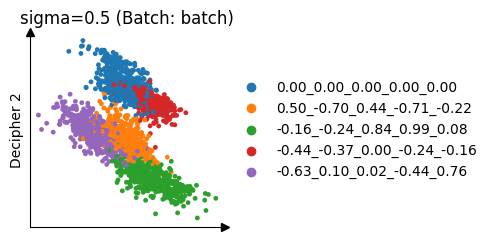

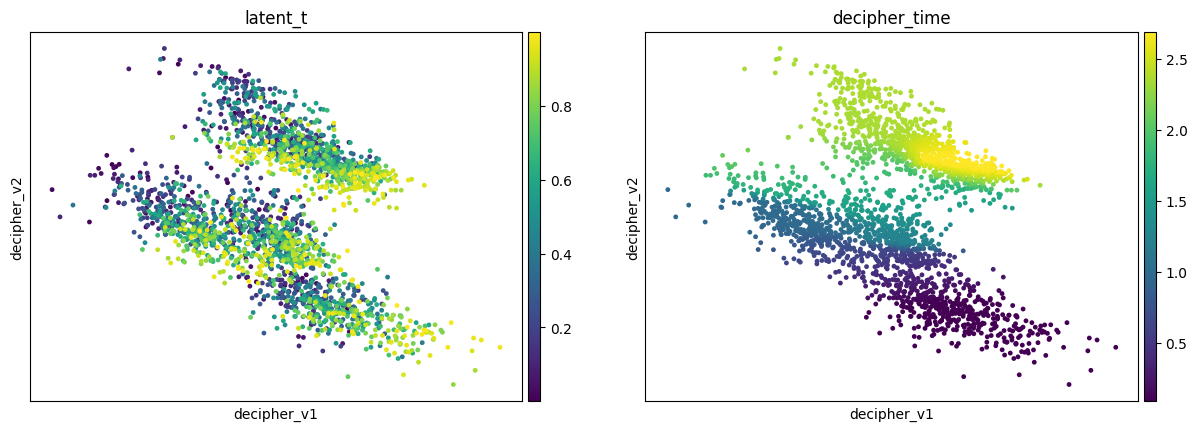

rho = 0.0855


In [6]:
import scanpy as sc

sc.pl.embedding(adata, basis="decipher_v", color=["latent_t", "decipher_time"])
print(f"rho = {rho:.4f}")

sigma=0.5  ground truth z silhouette (by batch) = 0.5256
sigma=0.5  learned decipher_z silhouette (by batch) = 0.7780


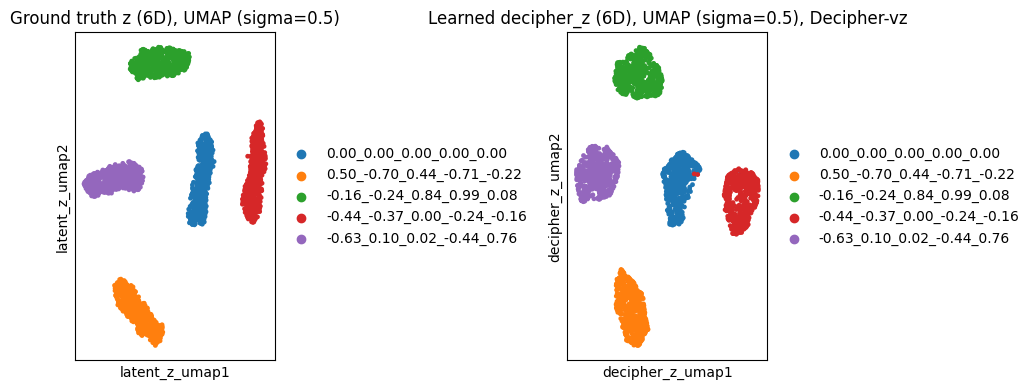

In [7]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# --- Quantitative: silhouette score directly on raw feature space (no projection) ---
# Ground truth uses all 6 latent_z dims (not just latent_z0/latent_z1) since the
# batch shift is now a 6D multivariate-normal vector applied across all dims.
batch_labels = adata.obs["batch"].astype(str)

sil_ground_truth = silhouette_score(
    adata.obs[["latent_z0", "latent_z1", "latent_z2", "latent_z3", "latent_z4", "latent_z5"]].values, batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
sil_learned = silhouette_score(
    adata.obsm["decipher_z"], batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
print(f"sigma={0.5}  ground truth z silhouette (by batch) = {sil_ground_truth:.4f}")
print(f"sigma={0.5}  learned decipher_z silhouette (by batch) = {sil_learned:.4f}")

# --- Qualitative: UMAP of ground truth z (6D, was a direct 2D scatter) vs. UMAP of learned decipher_z (6D) ---
adata.obsm["latent_z"] = adata.obs[["latent_z0", "latent_z1", "latent_z2", "latent_z3", "latent_z4", "latent_z5"]].values
sc.pp.neighbors(adata, use_rep="latent_z", key_added="latent_z_neighbors", random_state=42)
sc.tl.umap(adata, neighbors_key="latent_z_neighbors", random_state=42)
adata.obsm["latent_z_umap"] = adata.obsm["X_umap"]

sc.pp.neighbors(adata, use_rep="decipher_z", random_state=42)
sc.tl.umap(adata, random_state=42)
adata.obsm["decipher_z_umap"] = adata.obsm["X_umap"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
sc.pl.embedding(adata, basis="latent_z_umap", color="batch",
                ax=axes[0], show=False, title=f"Ground truth z (6D), UMAP (sigma={0.5})")
sc.pl.embedding(adata, basis="decipher_z_umap", color="batch",
                ax=axes[1], show=False, title=f"Learned decipher_z (6D), UMAP (sigma={0.5}), Decipher-vz")
plt.tight_layout()
plt.show()

## Test Run for Decipher-vz2
Testing decipher_vz2 (conditioning batch on z for encoder and decoder) at sigma=0.5, seed=0, decipher_seed=1, dim_z=6

Epoch 128 (batch 22/22) | | train elbo: 60.91 (last epoch: 61.27) | val ll: 72.10:  13%|█▎        | 128/1000 [00:26<03:01,  4.81it/s]2026-07-23 18:49:24,885 | INFO : Early stopping has been triggered.
2026-07-23 18:49:24,888 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-07-23 18:49:24,888 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-07-23 18:49:24,888 | INFO : Saving decipher model with run_id 2026-07-23-18-49-24-concurrent-ecru-alphabet.


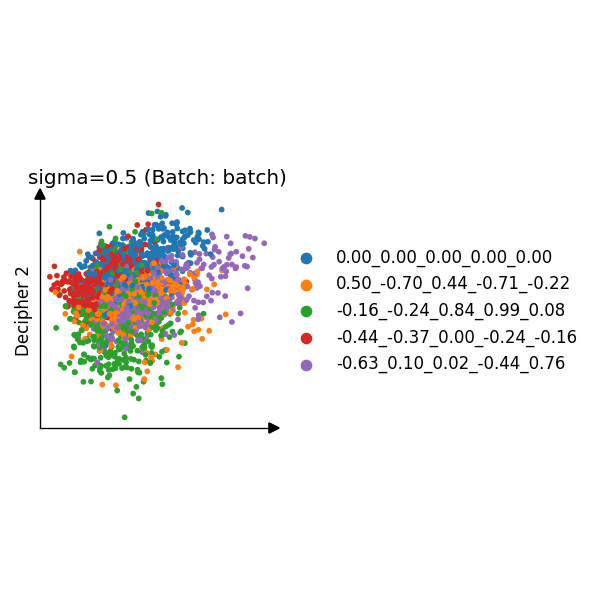

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
2026-07-23 18:49:25,342 | INFO : Clustering cells using scanpy Leiden algorithm.
2026-07-23 18:49:25,342 | INFO : Step 1: Computing neighbors with `sc.pp.neighbors`, with the representation decipher_z.
2026-07-23 18:49:25,364 | INFO : Step 2: Computing clusters with `sc.tl.leiden`, and resolution 0.05.
2026-07-23 18:49:25,672 | INFO : Added `.obs['decipher_clusters']`: the cluster labels.
/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/sigma_sweep_6dz.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defaul

rho = 0.0561
ground truth: /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/6dz_shift_sigma_sweep/0723_vz_sigma0.50.h5ad
trained:      /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/6dz_shift_sigma_sweep/trained/decipher_vz2/sigma0.5_seed0_decipher_vz2.h5ad


In [8]:
rho, gt_path, trained_path, adata = rho_for_run(sigma=0.5, seed=0, model="decipher_vz2", decipher_seed=1)
print(f"rho = {rho:.4f}")
print(f"ground truth: {gt_path}")
print(f"trained:      {trained_path}")

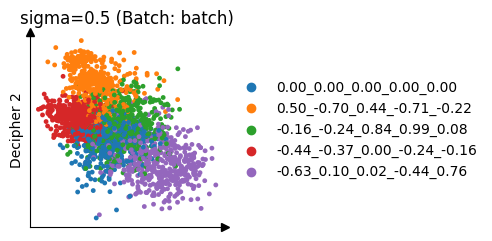

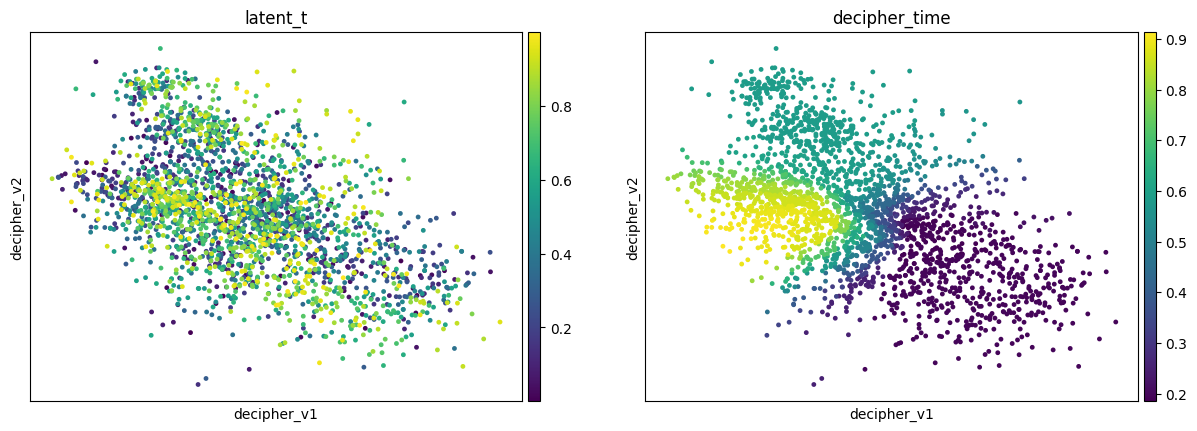

rho = 0.0561


In [9]:
import scanpy as sc

sc.pl.embedding(adata, basis="decipher_v", color=["latent_t", "decipher_time"])
print(f"rho = {rho:.4f}")

sigma=0.5  ground truth z silhouette (by batch) = 0.5256
sigma=0.5  learned decipher_z silhouette (by batch) = 0.5456


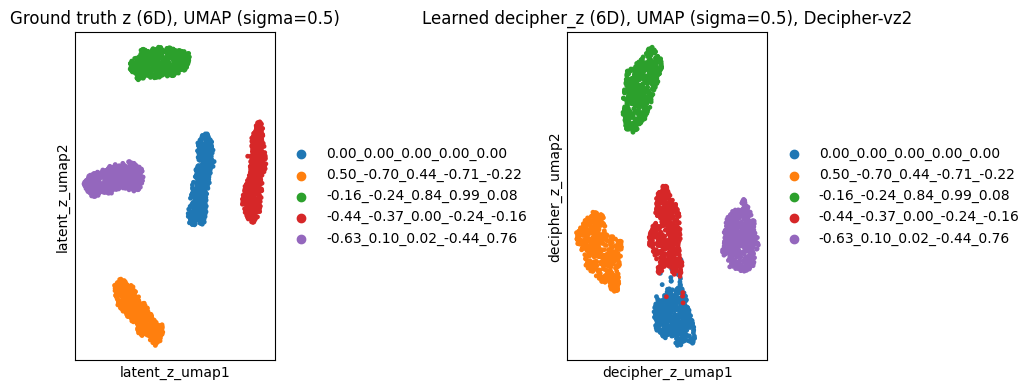

In [10]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# --- Quantitative: silhouette score directly on raw feature space (no projection) ---
# Ground truth uses all 6 latent_z dims (not just latent_z0/latent_z1) since the
# batch shift is now a 6D multivariate-normal vector applied across all dims.
batch_labels = adata.obs["batch"].astype(str)

sil_ground_truth = silhouette_score(
    adata.obs[["latent_z0", "latent_z1", "latent_z2", "latent_z3", "latent_z4", "latent_z5"]].values, batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
sil_learned = silhouette_score(
    adata.obsm["decipher_z"], batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
print(f"sigma={0.5}  ground truth z silhouette (by batch) = {sil_ground_truth:.4f}")
print(f"sigma={0.5}  learned decipher_z silhouette (by batch) = {sil_learned:.4f}")

# --- Qualitative: UMAP of ground truth z (6D, was a direct 2D scatter) vs. UMAP of learned decipher_z (6D) ---
adata.obsm["latent_z"] = adata.obs[["latent_z0", "latent_z1", "latent_z2", "latent_z3", "latent_z4", "latent_z5"]].values
sc.pp.neighbors(adata, use_rep="latent_z", key_added="latent_z_neighbors", random_state=42)
sc.tl.umap(adata, neighbors_key="latent_z_neighbors", random_state=42)
adata.obsm["latent_z_umap"] = adata.obsm["X_umap"]

sc.pp.neighbors(adata, use_rep="decipher_z", random_state=42)
sc.tl.umap(adata, random_state=42)
adata.obsm["decipher_z_umap"] = adata.obsm["X_umap"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
sc.pl.embedding(adata, basis="latent_z_umap", color="batch",
                ax=axes[0], show=False, title=f"Ground truth z (6D), UMAP (sigma={0.5})")
sc.pl.embedding(adata, basis="decipher_z_umap", color="batch",
                ax=axes[1], show=False, title=f"Learned decipher_z (6D), UMAP (sigma={0.5}), Decipher-vz2")
plt.tight_layout()
plt.show()

## Test Run for Decipher-mf
testing decipher_mf (mean field inference) at sigma=0.5, seed=0, decipher_seed=1, dim_z=6

Epoch 234 (batch 22/22) | | train elbo: 64.31 (last epoch: 64.28) | val ll: 64.16:  23%|██▎       | 234/1000 [00:50<02:45,  4.62it/s]2026-07-23 18:50:20,148 | INFO : Early stopping has been triggered.
2026-07-23 18:50:20,150 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-07-23 18:50:20,150 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-07-23 18:50:20,150 | INFO : Saving decipher model with run_id 2026-07-23-18-50-20-plain-livid-skillet.


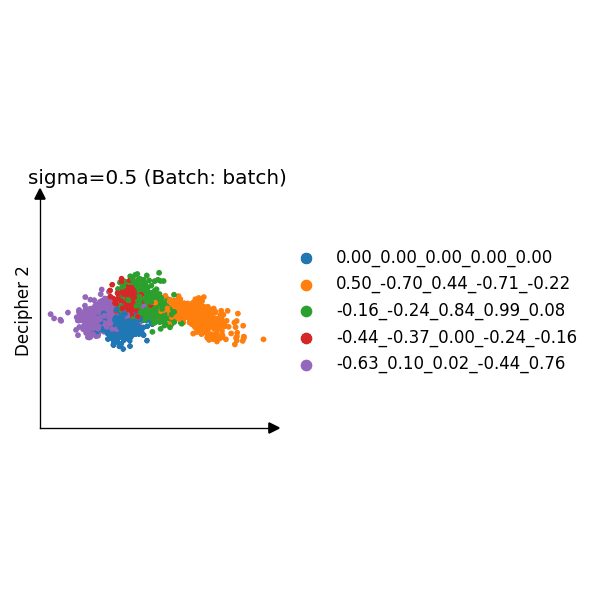

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
2026-07-23 18:50:20,879 | INFO : Clustering cells using scanpy Leiden algorithm.
2026-07-23 18:50:20,879 | INFO : Step 1: Computing neighbors with `sc.pp.neighbors`, with the representation decipher_z.
2026-07-23 18:50:20,902 | INFO : Step 2: Computing clusters with `sc.tl.leiden`, and resolution 0.05.
2026-07-23 18:50:21,164 | INFO : Added `.obs['decipher_clusters']`: the cluster labels.
/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/sigma_sweep_6dz.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defaul

rho = nan
ground truth: /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/6dz_shift_sigma_sweep/0723_vz_sigma0.50.h5ad
trained:      /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/6dz_shift_sigma_sweep/trained/decipher_mf/sigma0.5_seed0_decipher_mf.h5ad


/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/sigma_sweep_6dz.py:61: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(adata.obs["decipher_time"][m], adata.obs["latent_t"][m])


In [11]:
rho, gt_path, trained_path, adata = rho_for_run(sigma=0.5, seed=0, model="decipher_mf", decipher_seed=1)
print(f"rho = {rho:.4f}")
print(f"ground truth: {gt_path}")
print(f"trained:      {trained_path}")

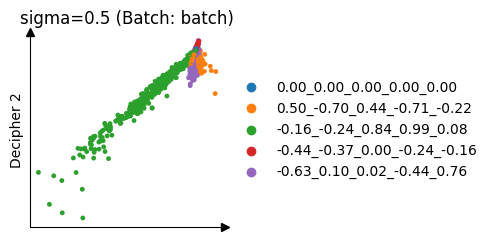

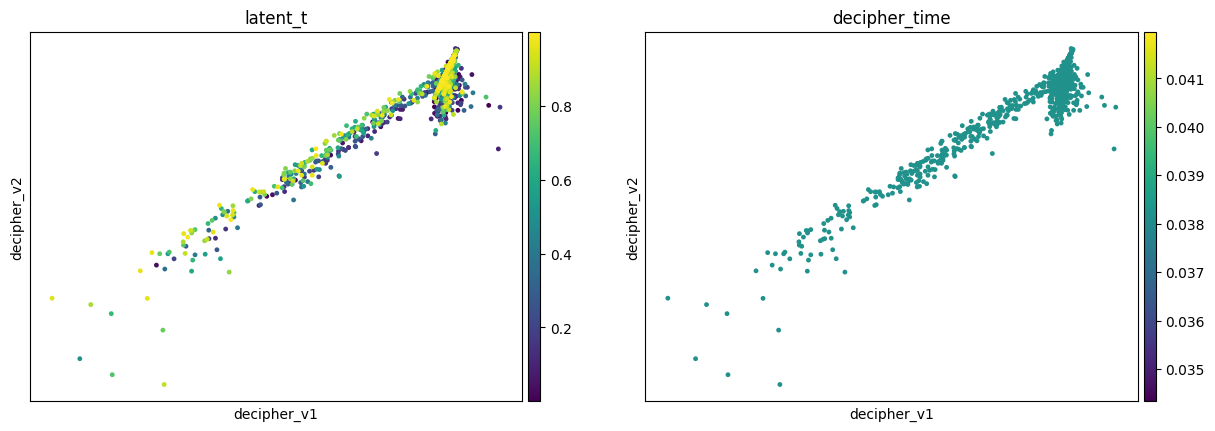

rho = nan


In [12]:
import scanpy as sc

sc.pl.embedding(adata, basis="decipher_v", color=["latent_t", "decipher_time"])
print(f"rho = {rho:.4f}")

sigma=0.5  ground truth z silhouette (by batch) = 0.5256
sigma=0.5  learned decipher_z silhouette (by batch) = 0.5661


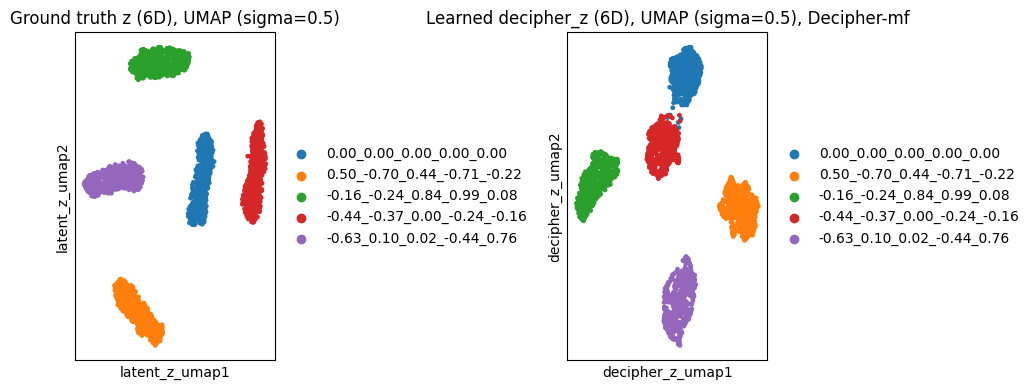

In [13]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# --- Quantitative: silhouette score directly on raw feature space (no projection) ---
# Ground truth uses all 6 latent_z dims (not just latent_z0/latent_z1) since the
# batch shift is now a 6D multivariate-normal vector applied across all dims.
batch_labels = adata.obs["batch"].astype(str)

sil_ground_truth = silhouette_score(
    adata.obs[["latent_z0", "latent_z1", "latent_z2", "latent_z3", "latent_z4", "latent_z5"]].values, batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
sil_learned = silhouette_score(
    adata.obsm["decipher_z"], batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
print(f"sigma={0.5}  ground truth z silhouette (by batch) = {sil_ground_truth:.4f}")
print(f"sigma={0.5}  learned decipher_z silhouette (by batch) = {sil_learned:.4f}")

# --- Qualitative: UMAP of ground truth z (6D, was a direct 2D scatter) vs. UMAP of learned decipher_z (6D) ---
adata.obsm["latent_z"] = adata.obs[["latent_z0", "latent_z1", "latent_z2", "latent_z3", "latent_z4", "latent_z5"]].values
sc.pp.neighbors(adata, use_rep="latent_z", key_added="latent_z_neighbors", random_state=42)
sc.tl.umap(adata, neighbors_key="latent_z_neighbors", random_state=42)
adata.obsm["latent_z_umap"] = adata.obsm["X_umap"]

sc.pp.neighbors(adata, use_rep="decipher_z", random_state=42)
sc.tl.umap(adata, random_state=42)
adata.obsm["decipher_z_umap"] = adata.obsm["X_umap"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
sc.pl.embedding(adata, basis="latent_z_umap", color="batch",
                ax=axes[0], show=False, title=f"Ground truth z (6D), UMAP (sigma={0.5})")
sc.pl.embedding(adata, basis="decipher_z_umap", color="batch",
                ax=axes[1], show=False, title=f"Learned decipher_z (6D), UMAP (sigma={0.5}), Decipher-mf")
plt.tight_layout()
plt.show()